# Monte Carlo Simulation

In this notebook, we demonstrate option pricing using **Monte Carlo (MC) simulation**.

We consider a **European call option** and evaluate the convergence of the MC estimator using different numbers of simulation paths, ranging from **500 to 500,000**. We examine three scenarios:

- No variance reduction
- Variance reduction using **antithetic variates**
- Variance reduction using a **control variate**

We compare the Monte Carlo results with the analytical price from the **Black-Scholes-Merton (BSM) model**.
The results show that the MC estimates, together with their **95% confidence intervals**, are consistent with the BSM price. Among the three approaches, the **control variate method** provides the most precise estimates by significantly reducing the estimator variance.

---
## Import Packages and Functions

In [21]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../src"))

from black_scholes_merton import price_option_bsm
from binomial_model import price_option_tree
from monte_carlo import price_option_mc

## 1. European Call option

We price a **European call option** using **Monte Carlo (MC) simulation** with different numbers of paths ranging from **500 to 500,000**.

We consider three approaches:

- No variance reduction
- Variance reduction using **antithetic variates**
- Variance reduction using a **control variate**

We visualize the estimated option prices and compare them with the analytical solution from the **Black-Scholes-Merton (BSM) model**, shown as the red horizontal dashed line in the plot.

The Monte Carlo estimates converge to the BSM price as the number of simulation paths increases. The **95% confidence intervals** illustrate the statistical uncertainty of the estimator. Among the three approaches, the **control variate method provides the most precise estimates**, as it significantly reduces the variance of the Monte Carlo estimator.

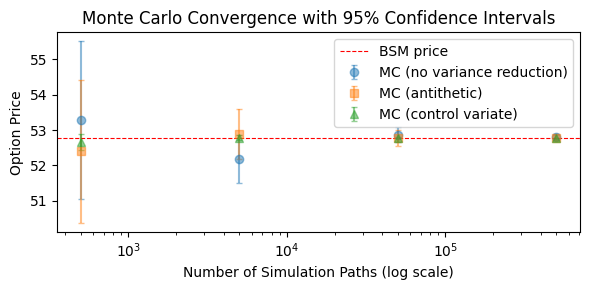

In [2]:
# parameters
seed = None

s = 100
k = 50
r = 0.1
sigma = 0.25
T = 1
q = 0.02

option_type = 'call'
exercise_style = 'European'

N_paths = np.asarray([500, 5000, 50000, 500000])

price1, price2, price3 = np.zeros(len(N_paths)), np.zeros(len(N_paths)), np.zeros(len(N_paths))
std1, std2, std3 = np.zeros(len(N_paths)), np.zeros(len(N_paths)), np.zeros(len(N_paths))

for i, n_paths in enumerate(N_paths):
    # no variance reduction
    price1[i], std1[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=False, control_variate=False, seed=seed)
    # antithetic variates
    price2[i], std2[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=True, control_variate=False, seed=seed)
    # control variate
    price3[i], std3[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=False, control_variate=True, seed=seed)

price_bsm = price_option_bsm(option_type, exercise_style, s, k, r, sigma, T, q)

# 95% confidence level
ci1 = 1.96*std1
ci2 = 1.96*std2
ci3 = 1.96*std3

plt.figure(figsize=(6,3))

plt.errorbar(N_paths, price1, yerr=ci1, fmt='o', capsize=2, alpha=0.5,
             label='MC (no variance reduction)')

plt.errorbar(N_paths, price2, yerr=ci2, fmt='s', capsize=2, alpha=0.5,
             label='MC (antithetic)')

plt.errorbar(N_paths, price3, yerr=ci3, fmt='^', capsize=2, alpha=0.5,
             label='MC (control variate)')

plt.axhline(price_bsm, linestyle='--', color='red', linewidth=0.8,
            label='BSM price')

plt.xscale('log')

plt.xlabel('Number of Simulation Paths (log scale)')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence with 95% Confidence Intervals')
plt.legend()

plt.tight_layout()
plt.show()

In [31]:

def price_american_lsmc(option_type, s, k, r, sigma, T, q, n_steps, n_paths, 
                        antithetic=False, control_variate=False, seed=None, return_exercise=False):

    if seed is not None:
        np.random.seed(seed)

    dt = T / n_steps
    discount = np.exp(-r * dt)

    # simulate stock paths
    if antithetic:
        half = (n_paths + 1) // 2
        Z_half = np.random.normal(size=(half, n_steps))
        Z = np.vstack([Z_half, -Z_half])[:n_paths]
    else:
        Z = np.random.normal(size=(n_paths, n_steps))

    
    stocks = np.zeros((n_paths, n_steps + 1))
    stocks[:,0] = s

    for t in range(1, n_steps + 1):
        stocks[:,t] = stocks[:,t-1] * np.exp(
            (r - q - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:,t-1]
        )

    # payoff matrix
    if option_type == 'call':
        payoff = np.maximum(stocks-k, 0)
    elif option_type == 'put':
        payoff = np.maximum(k-stocks, 0)
    else:
        raise ValueError('option_type must be call or put')
    
    # initialize cashflows at maturity
    cashflow = payoff[:,-1]

    exercise_matrix = np.zeros((n_paths, n_steps+1))

    # backward induction
    for t in range(n_steps-1, 0, -1):

        in_money = payoff[:,t] > 0

        X = stocks[in_money, t]
        Y = cashflow[in_money] * discount

        if len(X) == 0:
            cashflow *= discount
            continue

        # regression basis: [1, s, s**2]
        A = np.vstack([np.ones_like(X), X, X**2]).T
        beta = np.linalg.lstsq(A, Y, rcond=None)[0]

        continuation = beta[0] + beta[1]*X + beta[2]*X**2
        exercise = payoff[in_money, t]

        exercise_now = exercise > continuation

        idx = np.where(in_money)[0]
        exercise_matrix[idx[exercise_now], t] = 1

        cashflow[idx[exercise_now]] = exercise[exercise_now]
        cashflow[idx[~exercise_now]] *= discount

    # discount final cashflows from t=1 to t=0
    values = cashflow * discount
    final_values = values

    if control_variate:
        if option_type == "call":
            euro_payoff = np.maximum(stocks[:,-1] - k, 0)
        else:
            euro_payoff = np.maximum(k - stocks[:,-1], 0)
        euro_discounted = np.exp(-r*T) * euro_payoff

        cov = np.cov(values, euro_discounted)[0,1]
        var_control = np.var(euro_discounted, ddof=1)

        if var_control > 0:
            beta = cov / var_control
        else: # in case if var_control = 0 
            beta = 0

        price_bsm = price_option_bsm(option_type, 'European', s, k, r, sigma, T, q)

        adjusted = values + beta * (price_bsm - euro_discounted)
        final_values = adjusted
    
    price = np.mean(final_values)
    std_err = np.std(final_values, ddof=1) / np.sqrt(n_paths)

    if return_exercise:
        return price, std_err, exercise_matrix, stocks
    else:
        return price, std_err

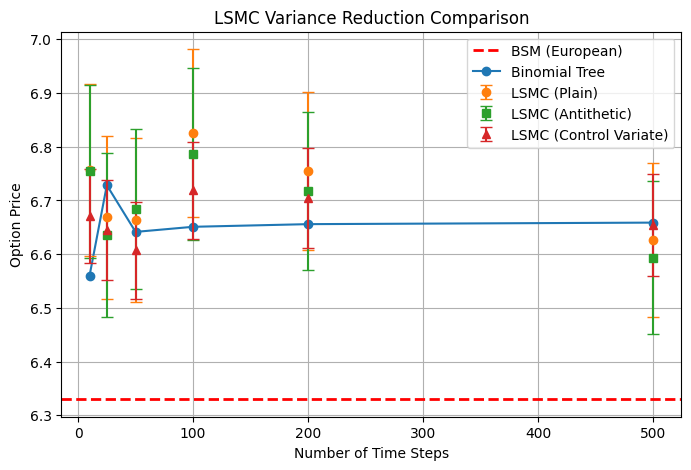

In [26]:
option_type = 'put'
exercise_style = 'American'

s = 100
k = 100
r = 0.05
sigma = 0.2
T = 1
q = 0.02

N_steps = [10, 25, 50, 100, 200, 500]
n_paths = 10000

# containers
price_tree = np.zeros(len(N_steps))

price_plain = np.zeros(len(N_steps))
stderr_plain = np.zeros(len(N_steps))

price_anti = np.zeros(len(N_steps))
stderr_anti = np.zeros(len(N_steps))

price_cv = np.zeros(len(N_steps))
stderr_cv = np.zeros(len(N_steps))

# baseline (European)
price_bsm = price_option_bsm(option_type, 'European', s, k, r, sigma, T, q)

for i, n_steps in enumerate(N_steps):

    # Binomial
    price_tree[i] = price_option_tree(
        option_type, exercise_style, s, k, r, sigma, T,
        N=n_steps, q=q, return_tree=False
    )

    # 1. Plain
    price_plain[i], stderr_plain[i] = price_american_lsmc(option_type, s, k, r, sigma, T, q,
        n_steps=n_steps, n_paths=n_paths, antithetic=False, control_variate=False, seed=42)

    # 2. Antithetic
    price_anti[i], stderr_anti[i] = price_american_lsmc(option_type, s, k, r, sigma, T, q,
       n_steps=n_steps, n_paths=n_paths, antithetic=True, control_variate=False, seed=42)

    # 3. Control variate
    price_cv[i], stderr_cv[i] = price_american_lsmc(option_type, s, k, r, sigma, T, q,
        n_steps=n_steps, n_paths=n_paths, antithetic=False, control_variate=True, seed=42)

# 95% CI
ci_plain = 1.96 * stderr_plain
ci_anti = 1.96 * stderr_anti
ci_cv = 1.96 * stderr_cv

plt.figure(figsize=(8, 5))

# BSM baseline
plt.axhline(y=price_bsm, linestyle='--', color='red', linewidth=2, label='BSM (European)')

# Binomial
plt.plot(N_steps, price_tree, marker='o', linestyle='-', label='Binomial Tree')

# LSMC - Plain
plt.errorbar(N_steps, price_plain, yerr=ci_plain, fmt='o', capsize=4, linestyle='none', label='LSMC (Plain)')

# LSMC - Antithetic
plt.errorbar(N_steps, price_anti, yerr=ci_anti, fmt='s', capsize=4, linestyle='none', label='LSMC (Antithetic)')

# LSMC - Control Variate
plt.errorbar(N_steps, price_cv, yerr=ci_cv, fmt='^', capsize=4, linestyle='none', label='LSMC (Control Variate)')

plt.xlabel('Number of Time Steps')
plt.ylabel('Option Price')
plt.title('LSMC Variance Reduction Comparison')

plt.legend()
plt.grid(True)

plt.show()

In [28]:
print(price_bsm, price_tree, price_plain, price_anti, price_cv)
print(ci_plain, ci_anti, ci_cv)

6.330080627549918 [6.56032926 6.7284121  6.64154874 6.65103032 6.65597412 6.65881589] [6.75657455 6.66869948 6.66405602 6.82569979 6.75494164 6.62675473] [6.75428475 6.63547763 6.68454396 6.78591303 6.71758582 6.59381182] [6.67039967 6.64509397 6.60737757 6.71902963 6.7040031  6.65431682]
[0.16047902 0.15135869 0.15246525 0.15586995 0.14772704 0.14300116] [0.1608365  0.15234273 0.14945456 0.15987417 0.14777018 0.14247804] [0.08761859 0.09268387 0.09065951 0.0907578  0.09327302 0.09444739]


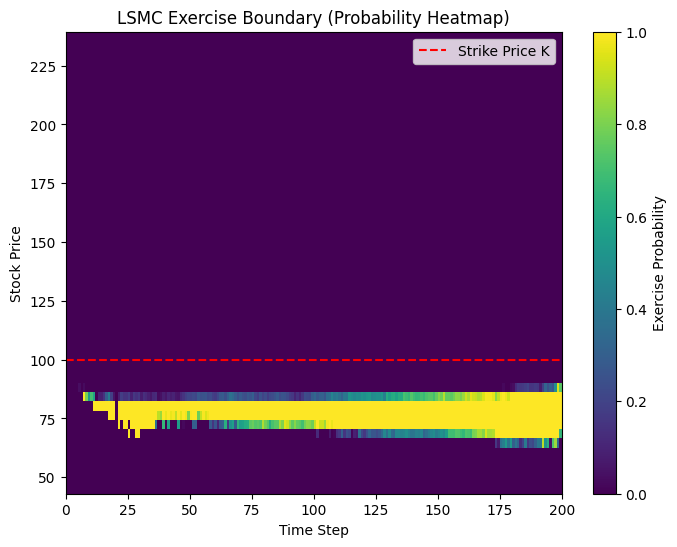

In [34]:
option_type = 'put'
exercise_style = 'American'

s = 100
k = 100
r = 0.05
sigma = 0.2
T = 1
q = 0.02

n_steps = 200
n_paths = 50000

price, std_err, exercise_matrix, stocks = price_american_lsmc(option_type, s, k, r, sigma, T, q, n_steps, n_paths, 
                                            antithetic=False, control_variate=True, seed=None, return_exercise=True)

n_bins = 50
S_min, S_max = stocks.min(), stocks.max()

bins = np.linspace(S_min, S_max, n_bins+1)

heatmap = np.zeros((n_bins, n_steps))
counts = np.zeros((n_bins, n_steps))

for t in range(1, n_steps):
    S_t = stocks[:, t]
    exercise_t = exercise_matrix[:, t]

    bin_idx = np.digitize(S_t, bins) - 1

    for i in range(n_paths):
        b = bin_idx[i]
        if 0 <= b < n_bins:
            heatmap[b, t] += exercise_t[i]
            counts[b, t] += 1

prob_exercise = np.divide(
    heatmap, counts,
    out=np.zeros_like(heatmap),
    where=counts > 0
)

plt.figure(figsize=(8, 6))

X = np.arange(n_steps + 1)  # time steps
Y = bins  # stock price bins

plt.pcolormesh(X, Y, prob_exercise, shading='auto', cmap='viridis')

plt.colorbar(label='Exercise Probability')

plt.axhline(k, color='red', linestyle='--', label='Strike Price K')

plt.xlabel('Time Step')
plt.ylabel('Stock Price')
plt.title('LSMC Exercise Boundary (Probability Heatmap)')

plt.legend()
plt.show()